In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
sys.path.insert(0, '..')
from lstm import AVERT_LSTM

import itertools
import tensorflow as tf
import keras

processed_dpath = '../processed_data/'

plt.rcParams.update(
    {
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "pdf.fonttype": 42,
        "font.family": "Avenir",
        "font.size": 18,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.pad": 6.5,
        "ytick.major.pad": 6.5,
    }
)

### Sarah Sandbox

/var/folders/k_/fnnxsv2n52qb5r1hq85f3p2c0000gn/T/ipykernel_87458/1048762736.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('12H').mean()
/Users/sarahshi/anaconda3/envs/phys/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Positive class weight: 10.81
Performing Training...
Epoch 1/100
16/16 - 2s - 131ms/step - accuracy: 0.7102 - loss: 1.2788 - precision_1: 0.0187 - recall_1: 0.0471 - val_accuracy: 0.9701 - val_loss: 0.8886 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/100
16/16 - 0s - 16ms/step - accuracy: 0.9153 - loss: 1.2724 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 0.8876 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/100
16/16 - 0s - 16ms/step - accuracy: 0.9153 - loss: 1.2698 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 0.8873 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 4/100
16/16 - 0s - 16ms/step - accuracy: 0.9153 - loss: 1.2675 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 0.8872 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 5/100
16/16 - 0s - 16ms/step - accuracy: 0.9153 - loss: 1.2653 - precision_1: 0.0

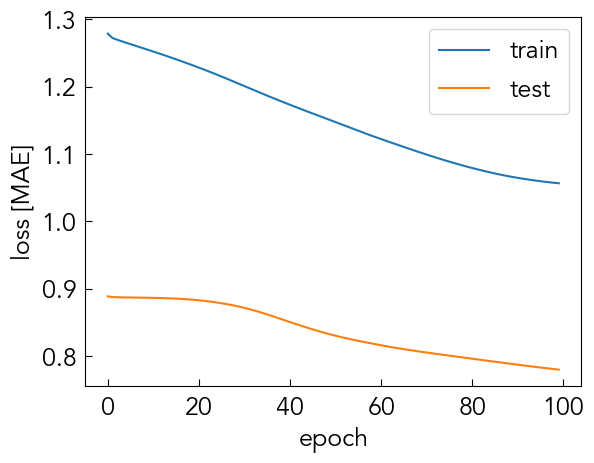

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [5]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

eps = 1e-6
df['log_VPCC_RSAM'] = np.log(df['VPCC_RSAM'].clip(lower=eps))
df['log_VPPC_RSAM'] = np.log(df['VPPC_RSAM'].clip(lower=eps))
df['log_VPNC_RSAM'] = np.log(df['VPNC_RSAM'].clip(lower=eps))
df['log_VPRS_RSAM'] = np.log(df['VPRS_RSAM'].clip(lower=eps))

# cut the range and resample to one data point per 12 hours
df = df.resample('12H').mean()
df['Eruption_Activity_Label'] = (df['Eruption_Activity'] > 0).astype(int)
input_vars = ['log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']
predict_vars = ['Eruption_Activity_Label']
# predict_vars = ['Eruption_Activity']
# predict_vars = ['Eruption_Activity', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']

# define model and plot data
lstm = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)
lstm.CreateModel(n_past=2, n_future=1, n_epochs=100, n_divide=0.75, n_neurons=400, learning_rate=1e-4, momentum=0.4, opt ='adam', activation='tanh', task_type='binary')
# lstm.model.summary()
lstm.Fit()
lstm.Predict()

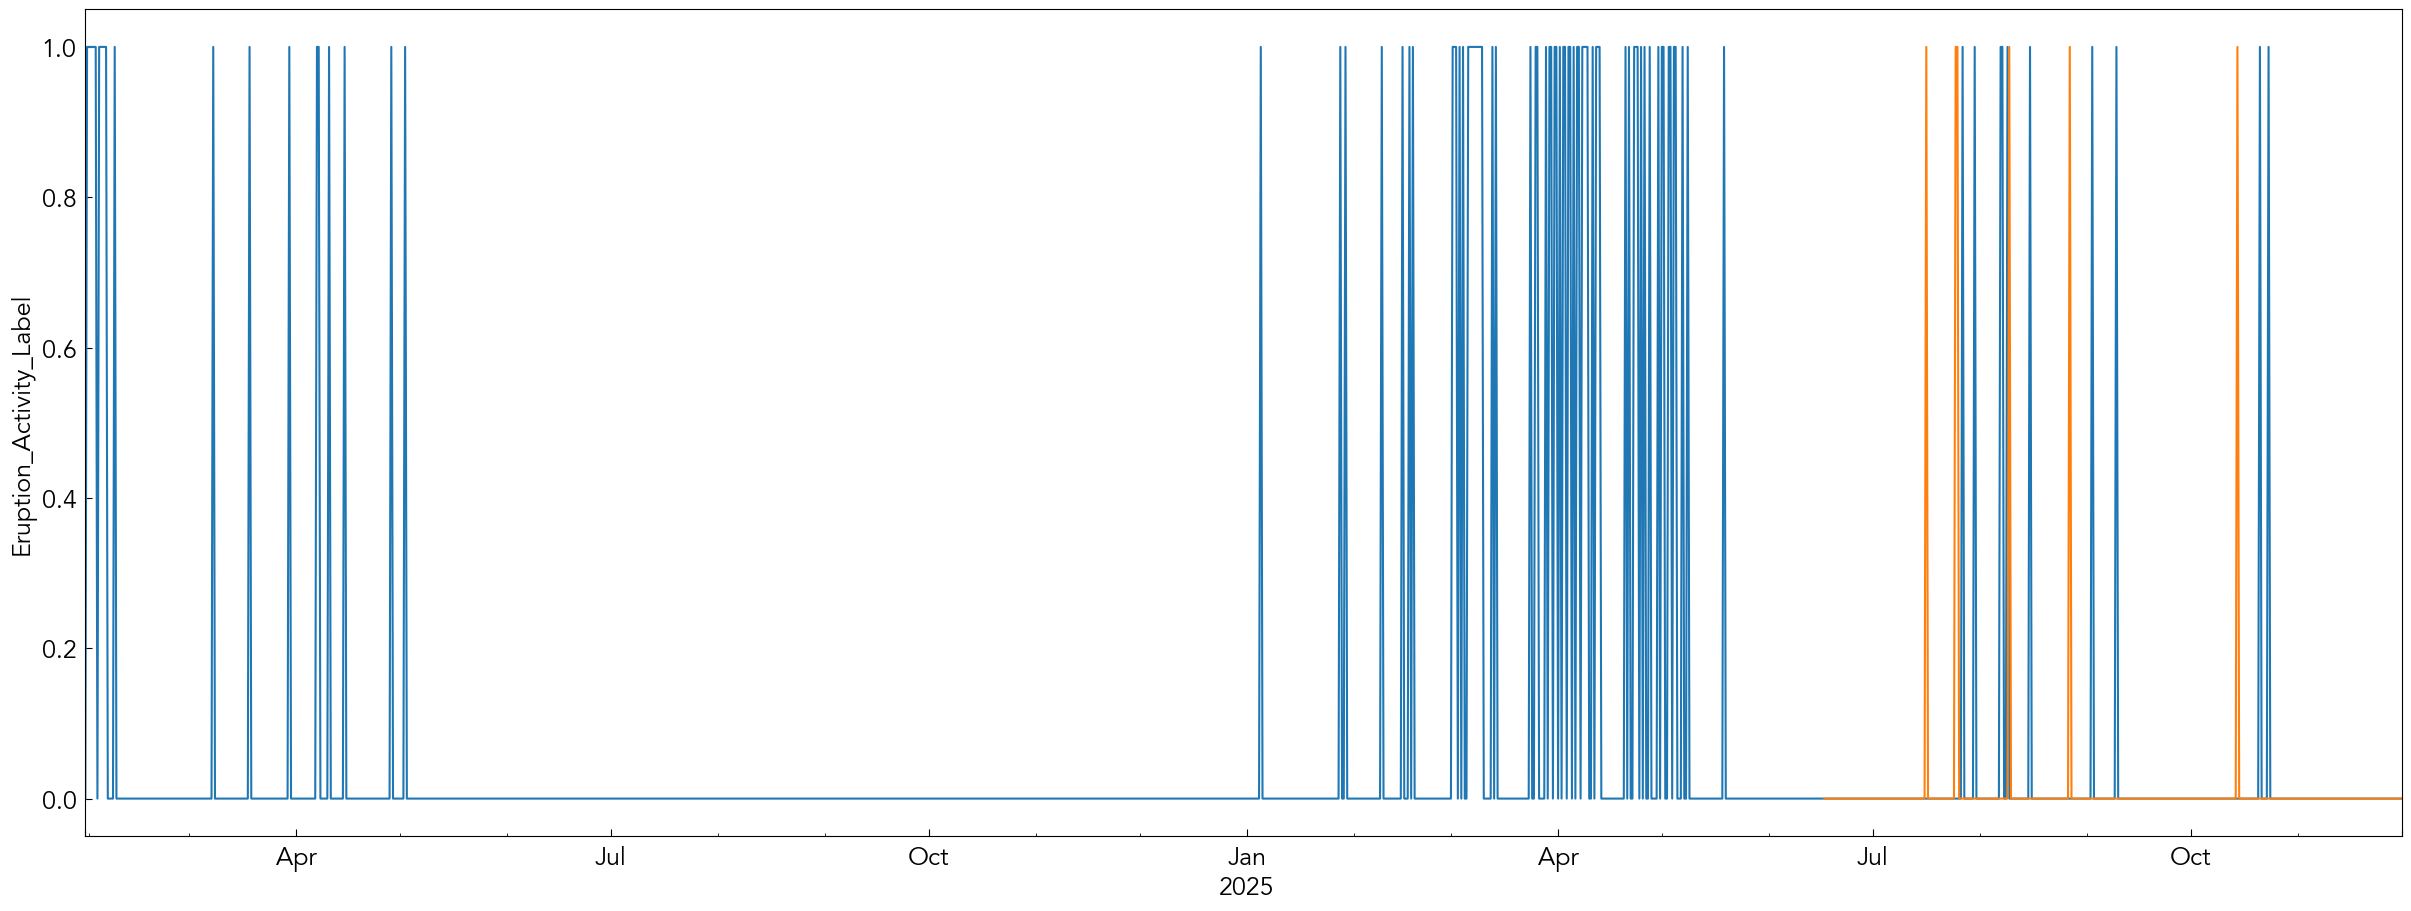

In [6]:
lstm.PlotData([lstm.df_y, lstm.df_yhat], log_vars=[])

/var/folders/k_/fnnxsv2n52qb5r1hq85f3p2c0000gn/T/ipykernel_87458/1036183783.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("12H").agg(agg)


Performing Training...
Epoch 1/200


/Users/sarahshi/anaconda3/envs/phys/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 - 2s - 97ms/step - loss: 0.2273 - mae: 0.2273 - mse: 0.1081 - val_loss: 0.2068 - val_mae: 0.2068 - val_mse: 0.0874
Epoch 2/200
16/16 - 0s - 14ms/step - loss: 0.1624 - mae: 0.1624 - mse: 0.0486 - val_loss: 0.1619 - val_mae: 0.1619 - val_mse: 0.0618
Epoch 3/200
16/16 - 0s - 15ms/step - loss: 0.1213 - mae: 0.1213 - mse: 0.0298 - val_loss: 0.1547 - val_mae: 0.1547 - val_mse: 0.0554
Epoch 4/200
16/16 - 0s - 15ms/step - loss: 0.0989 - mae: 0.0989 - mse: 0.0199 - val_loss: 0.1462 - val_mae: 0.1462 - val_mse: 0.0521
Epoch 5/200
16/16 - 0s - 14ms/step - loss: 0.0906 - mae: 0.0906 - mse: 0.0185 - val_loss: 0.1396 - val_mae: 0.1396 - val_mse: 0.0474
Epoch 6/200
16/16 - 0s - 14ms/step - loss: 0.0949 - mae: 0.0949 - mse: 0.0184 - val_loss: 0.1547 - val_mae: 0.1547 - val_mse: 0.0488
Epoch 7/200
16/16 - 0s - 14ms/step - loss: 0.1103 - mae: 0.1103 - mse: 0.0238 - val_loss: 0.1402 - val_mae: 0.1402 - val_mse: 0.0439
Epoch 8/200
16/16 - 0s - 14ms/step - loss: 0.0871 - mae: 0.0871 - mse: 0.0154 - v

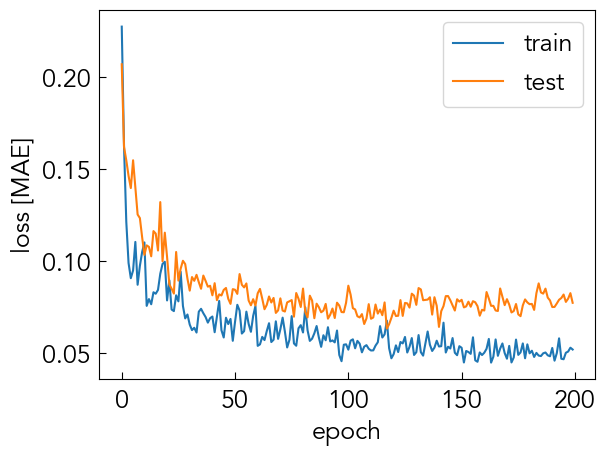

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Test RMSE: 0.139


In [8]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

eps = 1e-6
for s in ["VPCC_RSAM", "VPPC_RSAM", "VPNC_RSAM", "VPRS_RSAM"]:
    df[f"log_{s}"] = np.log(df[s].clip(lower=eps))

agg = {c: "mean" for c in df.columns}
agg["Eruption_Activity"] = "max"   # or "sum"
df = df.resample("12H").agg(agg)

# cut the range and resample to one data point per 12 hours
# df = df.resample('12H').mean()
# df['Eruption_Activity_Label'] = (df['Eruption_Activity'] > 0).astype(int)
input_vars = ['Eruption_Activity', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']
predict_vars = ['Eruption_Activity', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']

# define model and plot data
lstm = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)
# use 36 hours to forecast the next 12 hours
lstm.CreateModel(n_past=3, n_future=1, n_epochs=200, n_divide=0.75, n_neurons=400, learning_rate=1e-3, momentum=0.4, opt ='adam', activation='tanh', task_type='regression')
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
# lstm.PlotData([lstm.df_y, (lstm2.df_yhat > 0).astype(int)], log_vars=[])

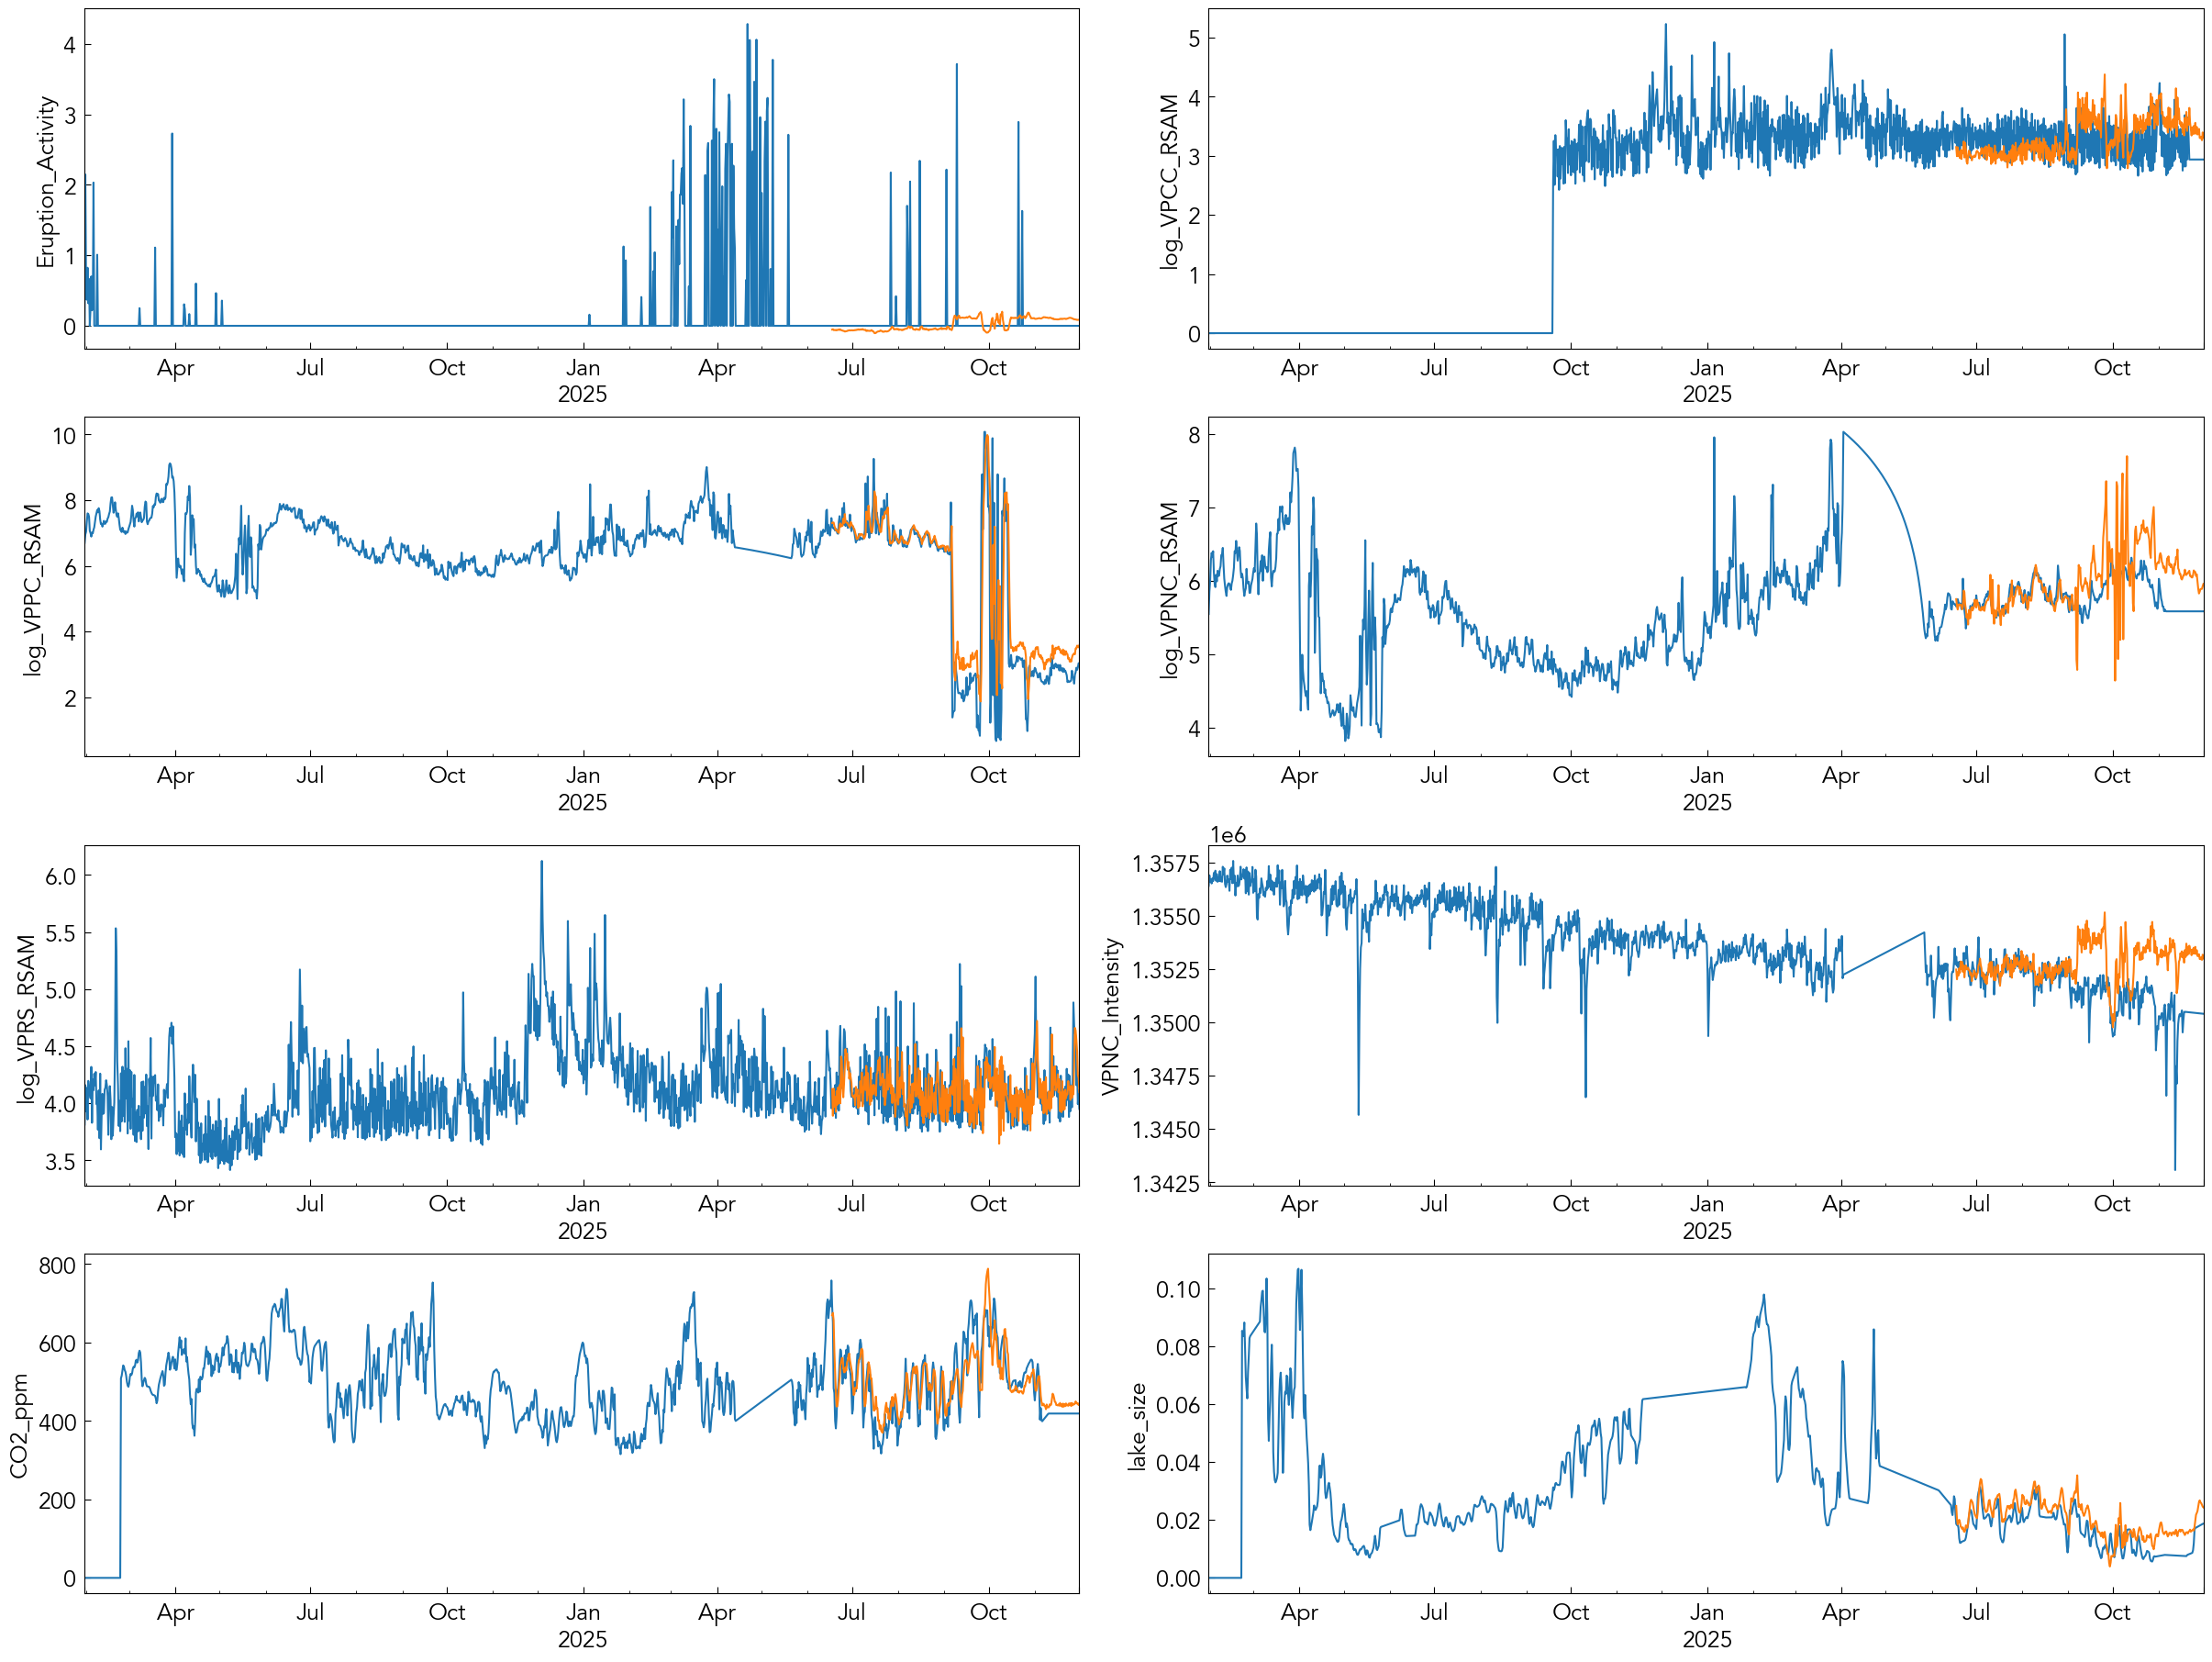

In [10]:
lstm.PlotData([lstm.df_y, lstm.df_yhat], log_vars=[])

# .loc[lstm.test_index]

## hyperparameter testing

In [ ]:

def evaluate_run(lstm, eruption_col="Eruption_Activity", eruption_thresh=0.0):
    # true values in timestamps as predictions
    y_true = lstm.df_y.loc[lstm.test_index]
    y_pred = lstm.df_yhat

    # align indices/cols
    y_true = y_true[y_pred.columns].loc[y_pred.index]

    # regression metrics
    mae_all = (y_true - y_pred).abs().mean().mean() # mean over time then over features ? 
    mae_eruption = (y_true[eruption_col] - y_pred[eruption_col]).abs().mean()

    # check how well it separates activity vs no-activity (threshold on truth)
    y_true_evt = (y_true[eruption_col] > eruption_thresh).astype(int).to_numpy()
    y_score = y_pred[eruption_col].to_numpy()

    # auc / roc 
    try:
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(y_true_evt, y_score) if len(np.unique(y_true_evt)) > 1 else np.nan
    except Exception:
        auc = np.nan

    return {
        "mae_all": float(mae_all),
        "mae_eruption": float(mae_eruption),
        "auc_eruption": float(auc),
        "eruption_rate_test": float(y_true_evt.mean()),
    }


def run_one(df, input_vars, predict_vars,
            n_past, n_future, n_epochs,
            n_divide, n_neurons, learning_rate, momentum,
            opt="adam", activation="tanh",
            task_type="regression",
            seed=42):

    # Reproducibility-ish
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Fresh instance each run
    lstm = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)

    lstm.CreateModel(
        n_past=n_past,
        n_future=n_future,
        n_epochs=n_epochs,
        n_divide=n_divide,
        n_neurons=n_neurons,
        learning_rate=learning_rate,
        momentum=momentum,
        opt=opt,
        activation=activation,
        task_type=task_type,
    )
    lstm.Fit()
    lstm.Predict()

    metrics = evaluate_run(lstm)
    return metrics


def grid_search(df, input_vars, predict_vars, grid, base_kwargs):
    results = []
    combos = list(itertools.product(*[grid[k] for k in grid.keys()]))

    for vals in combos:
        params = dict(zip(grid.keys(), vals))

        if params.get("opt", "adam") == "adam" and "momentum" in params and params["momentum"] not in (0.0, 0.9):
            # no momentum for adam 
            pass

        # clear state between runs
        keras.backend.clear_session()

        try:
            metrics = run_one(
                df, input_vars, predict_vars,
                **params,
                **base_kwargs,
            )
            row = {**params, **metrics}
            results.append(row)
            print(row)
        except Exception as e:
            row = {**params, "error": str(e)}
            results.append(row)
            print("failed: ", row)

    return pd.DataFrame(results)


In [ ]:
base_kwargs = dict(
    n_epochs=80,
    n_divide=0.75,
    activation="tanh",
    task_type="regression",
    seed=42,
)

grid = {
    "n_past": [3, 6, 12], # 36h, 72h, 144h at 12H sampling
    "n_future": [1, 2, 4], # 12h, 24h, 48h ahead
    "n_neurons": [32, 64, 128, 256, 512],
    "learning_rate": [1e-3, 3e-4],
    "opt": ["adam", "sgd"],
    "momentum": [0.0],
}

results = grid_search(df, input_vars, predict_vars, grid, base_kwargs)

# Rank by eruption MAE (lower is better), then overall MAE
# results_clean = results[~results.columns.isin(["error"])].copy()
results_clean = results.sort_values(["mae_eruption", "mae_all"])
display(results_clean.head(10))
